# 42 · Deep Learning Foundations: Complete Course Review
### Connect the model, objective, gradient, data split, and evidence

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Learning goal.</b> Design a small experiment from beginning to end, choose a model and output head that match the task, trace a training update, select a checkpoint correctly, and explain what the final result actually establishes.</div>

The shared pattern across the course is to represent an input, compute a prediction, measure an objective, propagate derivatives, and update parameters. The architecture changes how information is represented and combined. The target and objective specify what behavior is rewarded. The evaluation design determines whether observed success supports the intended claim.

The [code companion](42_Deep_Learning_Foundations_Review.ipynb) trains a small MLP on two-dimensional synthetic data. Its labels indicate whether the two coordinates have the same sign. It separates training, validation, and test examples, saves the checkpoint with the lowest validation loss, and compares final test accuracy with a majority-class baseline.

| Question to answer | Concrete artifact |
|---|---|
| What should the system predict? | Target definition and output format |
| What information may it use? | Inputs and visibility rules |
| What does training optimize? | Explicit loss with shape conventions |
| How will it improve? | Backward pass and optimizer |
| How will settings be chosen? | Validation protocol |
| How will success be assessed? | Held-out metric and meaningful baseline |


## 1. A map of all 42 lessons

| Notes | Central ideas | What to carry forward |
|---|---|---|
| 01–05 | Why deep learning; neurons; activations; MLPs; tensors and forward passes | A network is a composed, parameterized function |
| 06–09 | Losses; gradients; optimizers; the complete training loop | Learning requires a differentiable objective and repeated updates |
| 10–12 | Training failures; regularization; first complete network | Diagnose data and optimization before increasing complexity |
| 13–16 | Embeddings; CNNs; CNN components; batch normalization | Representation and architectural assumptions shape the computation |
| 17–19 | Image classification; transfer learning; self-supervision | Supervision can come from labels, pretrained representations, or data-derived targets |
| 20–22 | Image tensors; recurrent networks; backpropagation through time | Track both spatial axes and temporal state explicitly |
| 23–25 | LSTM; GRU; sequence modeling | Gates control memory; readouts and masks match sequence tasks |
| 26–30 | Attention; Transformers; positions; multiple heads; encoder/decoder structures | Visibility and tensor dimensions determine what can influence an output |
| 31–32 | BERT and GPT | Masked-token and next-token objectives use different context |
| 33–36 | Convolution arithmetic; CNN training; designs; detection and segmentation | Spatial output structure determines the head, labels, and metric |
| 37–40 | Generative distributions; autoencoders/VAEs; GANs; diffusion | Different learning objectives require different sampling procedures |
| 41–42 | Language-model foundations and cumulative review | Connect all components to a defensible experiment |

Use [the training loop](09_The_Complete_Training_Loop_Notes.ipynb) for execution order, [backpropagation](07_Gradients_and_Backpropagation_Notes.ipynb) for derivatives, [sequence modeling](25_Sequence_Modeling_Notes.ipynb) for readouts, and [generative foundations](37_Generative_Modeling_Foundations_Notes.ipynb) for distribution and sampling questions. The same words—input, output, target, loss—must be made concrete again for each task.


## 2. Choose an architecture from the input structure

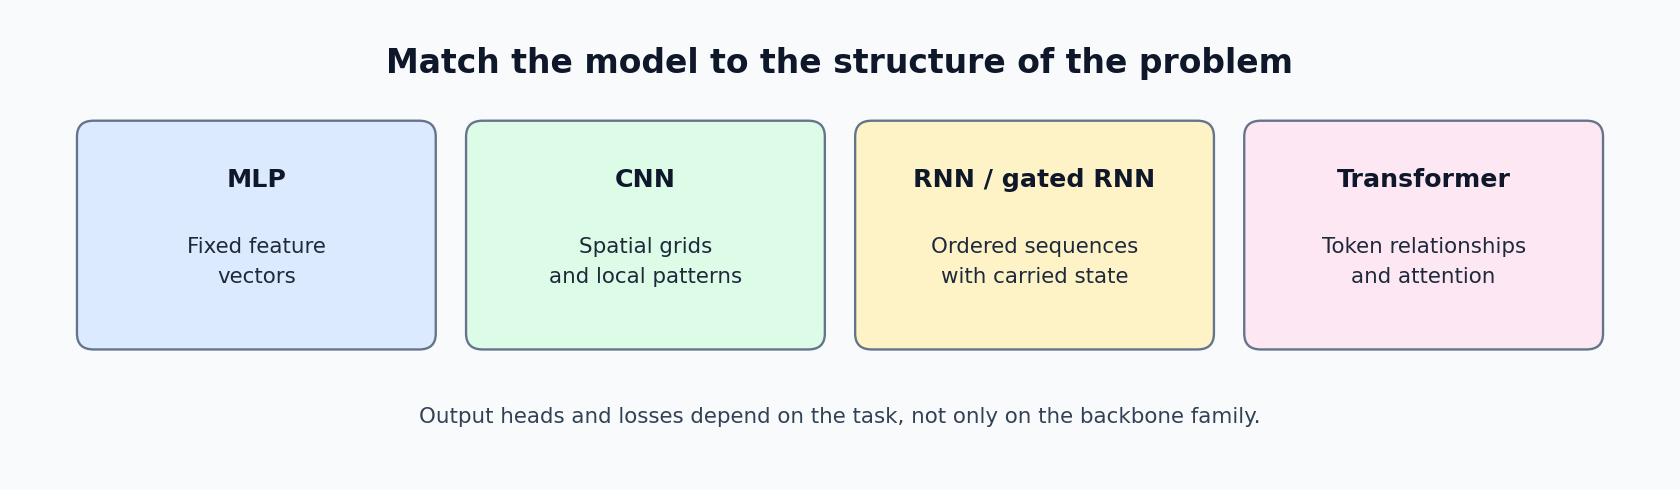

| Situation | Useful starting point | Architectural reason | Check before increasing size |
|---|---|---|---|
| Fixed feature vector | Linear model, then MLP | Combines supplied features | Scaling, leakage, baseline performance |
| Image classification | CNN | Local filters and shared weights | Channel order and label mapping |
| Pixel labeling | Spatial CNN with dense head | Keeps a prediction grid | Output resolution and pixel targets |
| Short sequence classification | Gated RNN or attention model | Combines ordered context | Length handling and readout position |
| Next-token prediction | Causal recurrent or attention model | Restricts access to preceding tokens | Shifted targets and visibility |
| Source-to-target sequence | Encoder/decoder | Conditions target production on source | Source mask, target mask, shifted decoder input |
| Reconstruction | Autoencoder | Learns an encoding and decoder | Reconstruction scale and bottleneck |
| Sampling new data | Specified generative model | Defines a training objective and sampler | Distribution, diversity, and held-out behavior |

These are starting points, not guarantees of superiority. A known rule can outperform a learned model when the task is explicitly constructed from that rule. A linear baseline can be sufficient if the supplied features already encode the needed nonlinear relationship.

Separate backbone from output head. A CNN may produce image classes, bounding boxes, or pixel logits depending on its head. An encoder representation can feed classification or other objectives. Choosing a family does not finish the design.


## 3. Match output, target, loss, and metric

| Task | Typical output | Target | Objective | Useful evaluation |
|---|---|---|---|---|
| Multiclass classification | `[B,K]` logits | `[B]` integer classes | Cross-entropy | Accuracy and class-wise errors |
| Binary classification | `[B]` logits | Matching binary values | Binary cross-entropy with logits | Threshold metrics and calibration |
| Regression | Predicted real values | Same-shaped values | MSE or another specified loss | MAE, RMSE, residual analysis |
| Token prediction | `[B,T,V]` or `[B,V]` logits | Corresponding token IDs | Masked or unmasked cross-entropy | Held-out loss and perplexity |
| Binary segmentation | `[B,1,H,W]` logits | Same spatial binary mask | Pixel-wise binary objective | IoU, Dice, per-image errors |
| Reconstruction | Reconstructed input | Observed input | Appropriate reconstruction objective | Held-out reconstruction and task-relevant quality |

Shape conventions vary by API. For example, a token head's `[B,T,V]` logits may need reshaping or permuting before a particular cross-entropy call. Always inspect the actual loss function's required axes.

<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>A metric and a loss have different roles.</b> The loss supplies the optimization signal. A metric summarizes behavior of interest. Accuracy can stay unchanged while cross-entropy improves because the correct class was already the argmax.</div>

For logits `[2,1]`, softmax probabilities are approximately `[0.7311,0.2689]`. If class 0 is correct, loss is approximately 0.3133. Logits `[4,1]` keep the same predicted class but raise its probability to approximately 0.9526 and reduce loss to approximately 0.0486. Both predictions contribute one correct example to accuracy.


## 4. Define the review companion's synthetic problem

The input has two coordinates, $x=(x_1,x_2)$, sampled from a standard normal distribution. The target rule is

$$
y=\mathbf{1}[x_1x_2>0].
$$

| Example | Product | Label | Meaning |
|---|---|---|---|
| $(1,1)$ | 1 | 1 | Both positive |
| $(-1,-1)$ | 1 | 1 | Both negative |
| $(1,-1)$ | −1 | 0 | Opposite signs |
| $(-1,1)$ | −1 | 0 | Opposite signs |
| $(0,2)$ | 0 | 0 | Strict inequality excludes the boundary |

Positive examples occupy two opposite quadrants. Negative examples occupy the other two. A single straight line cannot perfectly separate this pattern over the whole plane. For the four representative corner points above, each class has midpoint $(0,0)$; a strict linear separation would need to place that same midpoint on opposite sides, which is impossible.

An MLP can learn nonlinear features, making this a useful demonstration. However, the known product rule already solves the constructed task exactly. Alternatively, adding $x_1x_2$ as a feature makes the rule a threshold on one feature. The lesson is nonlinear representation and sound evaluation, not a claim that every such problem requires a neural network.


## 5. Split before selecting a model

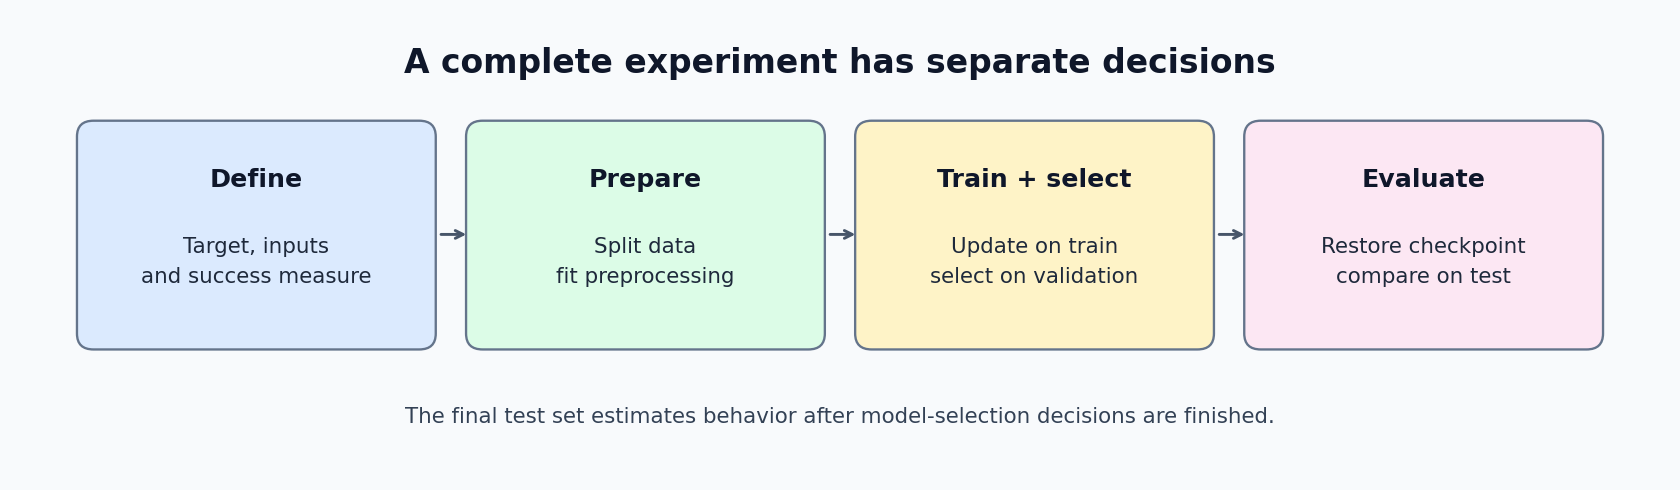

The companion draws 600 examples and uses fixed slices. Since they were generated independently from the same distribution, these slices are suitable for this small demonstration.

| Partition | Index range | Examples | Allowed purpose |
|---|---|---|---|
| Training | 0 through 399 | 400 | Compute gradients and fit parameters |
| Validation | 400 through 499 | 100 | Select the checkpoint by loss |
| Test | 500 through 599 | 100 | Evaluate the selected model |

For real data, the right split may require separating subjects, documents, locations, or time periods. Independent row splitting can be misleading when nearby records belong to the same entity. Fit scalers and other learned preprocessing on training data, then apply that fitted transformation to validation and test data.

The synthetic features are already sampled at unit scale, so the companion does not fit a scaler. Avoid interpreting this as a general rule that tabular features never need scaling.

An untouched test set loses that role if repeated test results guide architecture or learning-rate decisions. More experiments after inspecting test performance require a new evaluation plan, rather than relabeling the same test result as independent evidence.


## 6. Trace the MLP and parameter count

The model is `Linear(2,16) → Tanh → Linear(16,2)`. It returns two class logits, not a single sigmoid probability.

| Stage | Training shape | Parameters |
|---|---|---|
| Input | `[400,2]` | None |
| First affine transformation | `[400,16]` | $2\times16+16=48$ |
| Tanh | `[400,16]` | None |
| Output affine transformation | `[400,2]` | $16\times2+2=34$ |
| Integer targets | `[400]` | None |
| Mean cross-entropy | Scalar | None |

The network has **82 trainable parameters**. Validation and test forward passes replace the batch dimension 400 with 100. The feature and class dimensions stay unchanged.

For one example,

$$
a=W_1x+b_1,\quad h=\tanh(a),\quad z=W_2h+b_2.
$$

Tanh is applied elementwise. Without a nonlinear activation, the two affine layers would collapse into one affine transformation: $W_2W_1x+W_2b_1+b_2$. Adding width without a nonlinear operation would not solve the separating-line limitation.

Tanh's derivative is $1-\tanh^2(a)$. When absolute preactivations become large, this derivative becomes small; activation saturation is one reason to inspect input scales and optimization behavior.


## 7. Follow the gradient through the whole model

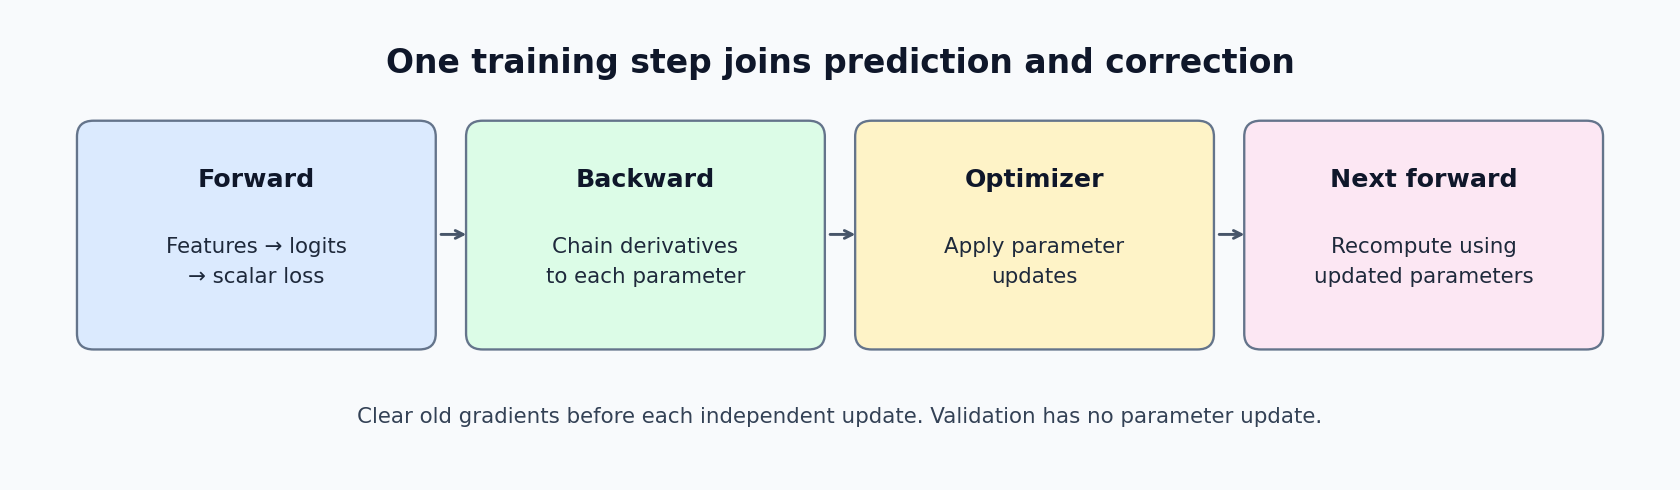

For a single example with class target $y$, let $p=\operatorname{softmax}(z)$. The output gradient is $g_z=p-\operatorname{onehot}(y)$.

$$
\nabla_{W_2}L=g_zh^\top,\quad \nabla_{b_2}L=g_z,
$$

$$
g_h=W_2^\top g_z,\quad g_a=g_h\odot(1-h^2),\quad
\nabla_{W_1}L=g_ax^\top,\quad\nabla_{b_1}L=g_a.
$$

These expressions are for one example; a mean batch loss averages the contributions. The outer products produce matrices with the same shapes as the corresponding weight matrices. A gradient is a local derivative of the current objective, not a guarantee that one step will improve every held-out example.

For a simple output-logit calculation, equal logits give probabilities `[0.5,0.5]`. If the label is 1, the gradient is `[0.5,-0.5]`. A teaching SGD step of size 0.1 on these logits produces `[-0.05,0.05]`, increasing class-1 probability to approximately 0.5250 and reducing loss from 0.6931 to 0.6444. The actual companion uses Adam to update the network's weights and biases.

Clear accumulated gradients before a new independent training step. Then compute the current forward pass, call backward on the scalar loss, and apply the optimizer. Clearing gradients after backward but before stepping would erase the update signal.


## 8. Read the training and checkpoint-selection loop

The random seed is 42. The companion performs 100 full-batch updates using Adam with learning rate 0.02. Every update uses all 400 training examples. After each update, it computes validation loss without recording gradients.

| Step | Data used | Does it change learned parameters? |
|---|---|---|
| Training forward and loss | Training | Forward alone does not |
| Backward pass | Training objective | Computes gradients |
| Adam step | Training gradients | Yes |
| Validation forward and loss | Validation | No |
| Save improved checkpoint | Validation comparison | Copies current parameter values |
| Restore selected checkpoint | Saved model state | Replaces final-step values |
| Final evaluation | Test | No optimizer step |

The saved state uses `value.clone()` for each state-dictionary tensor. This matters: the best checkpoint must preserve the values from that update, rather than retain references to tensors that future optimizer steps modify. The model restores that saved state before evaluating test accuracy.

`torch.no_grad()` controls gradient recording. `model.eval()` controls behavior of modules such as dropout and batch normalization. They solve different problems. The current MLP has neither dropout nor batch normalization, so mode-dependent layer behavior is absent here; a larger network may require both evaluation mode and disabled gradients during evaluation.


## 9. Why select validation loss and report test accuracy?

Validation loss uses probabilities and can distinguish checkpoints whose hard predictions are identical. The companion saves the smallest observed validation cross-entropy. This is a stated selection rule, not necessarily the checkpoint with highest validation accuracy.

The final model is evaluated on the test set using argmax class predictions. The majority-class baseline chooses the most frequent **training** label and predicts it for every test example.

| Reported quantity | What it measures | What it does not establish |
|---|---|---|
| Best validation loss | Selection objective on the validation set | Independent final performance |
| Test accuracy | Fraction of 100 correct test predictions | Calibration or performance on new distributions |
| Majority test accuracy | Simple training-derived constant predictor | Strong nonlinear baseline performance |
| Accuracy-range assertion | Score lies between 0 and 1 | Score beats the baseline |

A one-example difference changes this test accuracy by one percentage point. A small test set can therefore produce visible run-to-run variation. Multiple independent seeds or larger test sets can strengthen an estimate if that investigation is part of the experiment design.

Because the population rule is symmetric, both classes are equally likely under the continuous independent standard-normal sampling. Finite training samples need not contain exactly 200 examples of each class, so the observed majority baseline is not forced to be exactly 50%.


## 10. Evaluate class errors, not only the average

Suppose a separate teaching experiment on 100 examples has the following confusion matrix. Rows are true classes and columns are predicted classes.

| True class | Predicted 0 | Predicted 1 | Total |
|---|---|---|---|
| 0 | 42 | 8 | 50 |
| 1 | 5 | 45 | 50 |
| Total | 47 | 53 | 100 |

Accuracy is $(42+45)/100=0.87$. For class 1, precision is $45/53\approx0.8491$, recall is $45/50=0.9$, and F1 is $90/(90+8+5)=90/103\approx0.8738$. These are illustrative counts, not results claimed from executing the companion.

Inspect errors by quadrant and distance from the axes. The label changes at an axis, so small coordinate changes near a boundary can change the correct class. If errors cluster only in one quadrant, an overall score may conceal a representation or training issue.

For detection and segmentation, similarly inspect spatial mistakes rather than carrying classification accuracy over unchanged. [Dense prediction](36_Beyond_Image_Classification_Notes.ipynb) explains why background-heavy pixel accuracy can hide poor foreground overlap.


## 11. Connect sequence models and attention to the same experiment logic

| Concept | Recurrent interpretation | Attention interpretation |
|---|---|---|
| Representation | Hidden state updated over time | Token vectors transformed using weighted reads |
| Order | State-update order | Positions plus visibility structure |
| Context restriction | State and selected inputs | Attention mask and supplied context |
| Sequence readout | Final/selected state or all states | Selected/pool token vectors or all positions |
| Training target | Task-specific labels or shifted sequence | Task-specific labels, masked tokens, or shifted sequence |

An LSTM gate is not an attention weight. Gates control updates and retention in recurrent memory. Attention weights describe a query's normalized weighting of visible value vectors. Both are learned computations, but they operate differently.

In self-attention, compatible dimensions are needed for the query/key dot product and value-weighted output. In a causal next-token model, later tokens must not influence an earlier prediction. Padding masks address nonexistent input positions; causal masks address forbidden future visibility. Neither replaces the need to exclude padded target positions from loss when applicable.

Return to [LSTM](23_LSTM_Networks_Notes.ipynb), [attention](26_Attention_Mechanism_Notes.ipynb), and [language foundations](41_Language_Model_Foundations_Notes.ipynb) when tracing a particular shape or target construction.


## 12. Connect generative models without confusing their objectives

| Family | Training idea | How a new sample is obtained | Evidence to inspect |
|---|---|---|---|
| Autoregressive | Predict the next observed item | Repeatedly predict and append | Held-out likelihood and generated sequences |
| Plain autoencoder | Reconstruct observed inputs | Needs a separate latent-sampling design | Reconstruction and representation usefulness |
| VAE | Reconstruction plus posterior/prior regularization | Sample prior latent, decode | Reconstruction, KL behavior, prior samples |
| GAN | Alternate discriminator and generator objectives | Sample generator input noise, run generator | Distribution coverage, diversity, realistic outputs |
| Diffusion | Learn a noise-level-conditioned denoising task | Run a specified reverse sampler | Noise prediction and complete generated samples |

Training a denoiser alone does not implement a diffusion sampler. Low reconstruction error alone does not demonstrate useful prior sampling. A GAN discriminator loss alone does not establish broad sample coverage. These distinctions are all instances of the same review question: does the measurement support the claimed behavior?

For any generative experiment, specify the data distribution, conditioning inputs, sampling algorithm, and evaluation procedure. A visually pleasing individual sample and an aggregate distribution assessment provide different evidence. Do not replace one with the other without explaining what the task requires.


## 13. A complete pre-training checklist

| Area | Concrete check | Why it matters |
|---|---|---|
| Data | Inspect actual examples and labels | Detect mapping errors and impossible targets |
| Splits | Exclude overlapping entities or future information | Prevent leakage |
| Preprocessing | Fit learned transformations on training only | Preserve held-out meaning |
| Shapes | Trace one example and one batch | Catch wrong axes before training |
| Objective | Confirm logits, IDs, masks, reductions | Optimize the intended quantity |
| Baseline | Run a simple prediction rule | Establish whether added complexity helps |
| Gradients | Confirm intended parameters receive finite gradients | Detect broken computation paths |
| Small fit | Try a tiny training subset when debugging | Check whether learning is possible |
| Selection | State the validation criterion in advance | Make checkpoint choice reviewable |
| Evaluation | Restore selected state and report held-out metrics | Avoid evaluating an unintended checkpoint |

For reproducibility, record the seed, split construction, architecture, objective, optimizer settings, checkpoint rule, and software environment. A seed helps reproduce one run; it does not show that a result is stable across seeds or data samples.

Choose the checks that fit the model. Image axis inspection is essential for a CNN; temporal visibility is essential for next-token attention; the generator/discriminator gradient path is essential for a GAN. A generic checklist becomes useful only when connected to the actual tensors and claims.


## 14. Diagnose failures using observations

| Observation | Possible explanation | Next useful check |
|---|---|---|
| Training loss stays flat | Wrong targets, broken gradients, unsuitable step size | Tiny-batch fit and parameter-gradient inspection |
| Training improves, validation worsens | Overfitting or distribution mismatch | Split quality, regularization, earlier checkpoint |
| Both losses high | Insufficient features, optimization issue, difficult task | Baselines, scales, capacity, objective |
| Sudden nonfinite loss | Numerical instability or excessive updates | Locate first nonfinite activation or gradient |
| Accuracy high, rare class poor | Class imbalance | Confusion matrix and per-class metrics |
| Validation suspiciously perfect | Leakage or trivially repeated examples | Duplicate/entity and preprocessing checks |
| CNN output grid wrong | Stride, padding, or dilation misunderstanding | Compute each spatial output dimension |
| Sequence output wrong near padding | Mask/readout mismatch | Valid lengths and target exclusion |
| GAN loses diversity | Mode collapse or unstable game | Multiple samples and distribution coverage |
| Diffusion prediction works but no samples exist | Reverse loop absent | Specify and implement the sampler separately |

Do not treat every failure as a request for a deeper network. First connect the symptom to the part of the experiment that can produce it. A correct model with mislabeled examples still optimizes the wrong task. A correct loss with leaked evaluation still produces misleading evidence.

<div style="background:#FCE7F3;border-left:6px solid #DB2777;padding:14px;border-radius:8px"><b>Evidence ladder.</b> A notebook running without errors establishes execution. Shape and arithmetic checks establish local correctness. Training behavior establishes fit to supplied examples. Held-out measurements and relevant baselines support performance claims.</div>


## 15. Worked experiment-design scenarios

**A. Classify images from several patients.** Split by patient before augmentation. A CNN learns local spatial features; its head returns class logits. Compare with a suitable baseline, select using validation data, and evaluate on excluded patients. Images from the same patient in both training and test would undermine the intended generalization claim.

**B. Predict the next character in repeated text.** Construct context/target windows, verify the selected target, and compare uniform, unigram, and bigram predictors. Separate genuinely different text for evaluation. A random split of overlapping windows or repeated phrases mainly measures fit to a familiar pattern.

**C. Label foreground pixels.** Preserve or recover a spatial grid, align image/mask transforms, and compute a dense objective. Inspect IoU or Dice and individual masks. An image-level class prediction cannot answer which pixels belong to the object.

**D. Generate new samples with a VAE.** Train the encoder/decoder objective, inspect held-out reconstructions and posterior behavior, then sample latents from the chosen prior and decode. Good reconstruction of observed examples is not the same experiment as generation from fresh prior samples.

**E. Reproduce the review classifier.** Keep the 400/100/100 split, two-logit head, Tanh hidden layer, and validation-loss checkpoint rule explicit. Compare the restored model to the training-majority baseline. Remember that the data's known product rule is an exact analytical reference, so the experiment demonstrates learned nonlinear prediction rather than discovering an unknown law.


## 16. Cumulative practice with answers

1. **Why does a linear–linear network remain linear in its input?** Composition gives $W_2W_1x+W_2b_1+b_2$, an affine function. A nonlinear activation changes this limitation.
2. **How many parameters are in the review MLP?** First layer 48, second 34, total 82. Tanh contributes none.
3. **Can validation loss improve while accuracy stays constant?** Yes. Correct-class probabilities may improve without changing argmax predictions.
4. **Why clone checkpoint tensors?** To retain selected values while later updates modify the active model's parameters.
5. **Where should a feature scaler be fitted?** Training data only; apply that fitted scaler to validation and test examples.
6. **Why does `no_grad()` not replace `eval()`?** The former disables gradient recording; the latter changes behaviors such as dropout and batch normalization.
7. **What does a finite-loss assertion prove?** The checked loss is neither NaN nor infinite. It does not prove accuracy, generalization, or baseline improvement.
8. **Are padding and causal masks interchangeable?** No. One excludes padding; the other prevents forbidden future reads.
9. **Does an autoencoder reconstruction objective specify a good latent prior?** No. A sampling distribution needs a separate design or a model such as a VAE that explicitly relates posterior and prior.
10. **Is the product-label problem evidence that neural networks are always necessary?** No. The known product rule solves it exactly; learned nonlinear features illustrate one modeling approach.
11. **For a uniform ten-token distribution, what are loss and perplexity?** Loss $\ln10\approx2.302585$ nats and perplexity 10.
12. **What result would be needed before claiming this review model beats its baseline?** Actual held-out measurements for the restored selected model and the stated baseline, using the same test examples.

### Final independent exercise

Choose a small task and write down its inputs, target, split unit, baseline, architecture, shape trace, objective, optimizer, selection rule, and final metric. Then explain one likely leakage path and one plausible optimization failure. A complete explanation connects these decisions to the task rather than naming components without showing how they interact.

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:16px;border-radius:8px"><b>Course completion standard.</b> You can explain what information enters a model, what output it produces, why the loss rewards the desired behavior, how derivatives reach its parameters, and what evidence supports using the result on new examples.</div>
